# Proyecto 1 — DATA1002

## Pregunta analítica

**¿Qué grupos de personas de 18 años o más, según su edad, sexo y estado civil, reportan menor satisfacción con la vida?**

Siguiendo la aclaración del profesor, el análisis se realiza únicamente con personas de **18 años o más**.  
No se realiza ningún filtro por Bogotá ni por lugar de residencia.


# 1. Entendimiento del problema

### Pregunta cuantitativa

**¿Qué grupos de personas de 18 años o más, según su edad, sexo y estado civil, reportan menor satisfacción con la vida?**


### Información necesaria para responder la pregunta

Antes de revisar la base de datos, necesitamos:

- La **edad** de cada persona para poder comparar diferentes grupos de edad.
- El **sexo** para comparar los niveles de satisfacción entre los grupos disponibles en la encuesta.
- El **estado civil** para observar si existen diferencias entre sus categorías.
- Una medida de **satisfacción con la vida** que permita comparar los grupos.
- Identificar únicamente a las personas de **18 años o más**.
- Comparar principalmente la **media, mediana y distribución** de la satisfacción con la vida en cada grupo.

Con esta información podemos identificar cuáles grupos presentan valores de satisfacción más bajos. El análisis será descriptivo, por lo que las diferencias encontradas no se interpretarán automáticamente como relaciones causales.


# 2. Preparación de los datos (ETL)

### Librerías

Usamos `pandas` para leer la tabla y `Path` para ubicar el archivo dentro del proyecto.

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-n63fae_i because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


### Ruta del archivo original

La ruta funciona si el notebook se ejecuta desde la raíz del proyecto o desde la carpeta `notebooks`.

In [2]:
ruta_proyecto = Path.cwd()
if ruta_proyecto.name == 'notebooks':
    ruta_proyecto = ruta_proyecto.parent

ruta_datos = ruta_proyecto / 'datos' / 'raw' / 'caracteristicas_composicion_hogar.csv'
print('Archivo de entrada:', ruta_datos.relative_to(ruta_proyecto))
print('¿Existe el archivo?', ruta_datos.exists())

Archivo de entrada: datos/raw/caracteristicas_composicion_hogar.csv
¿Existe el archivo? True


### Carga de los datos

El archivo separa columnas con punto y coma (`;`) y escribe decimales con coma. Por eso se indican `sep=';'` y `decimal=','`.

In [3]:
df = pd.read_csv(ruta_datos, sep=';', decimal=',')
print('Filas y columnas:', df.shape)

Filas y columnas: (235350, 78)


### Inspección inicial

Revisamos nombres de columnas, algunas filas y tipos de datos. La vista de filas se limita a 12 columnas para que sea fácil de leer. Aún no interpretamos los códigos de las variables.

In [4]:
print('Nombres de las columnas:')
print(df.columns.tolist())

display(df.iloc[:3, :12])
df.info()

Nombres de las columnas:
['DIRECTORIO', 'SECUENCIA_ENCUESTA', 'SECUENCIA_P', 'ORDEN', 'FEX_C', 'P6016', 'P1894', 'P6020', 'P6034', 'P6040', 'P6051', 'P5502', 'P6071', 'P6071S1', 'P756', 'P756S1', 'P756S2', 'P756S3', 'P3510', 'P3510S1', 'P3510S1A1', 'P3510S1A2', 'P3510S1A3', 'P3510S1A4', 'P3510S1A5', 'P3510S1A6', 'P3510S1A7', 'P3510S1A8', 'P3510S1A9', 'P3510S1A10', 'P3510S1A11', 'P3510S2', 'P3510S2A1', 'P3510S2A2', 'P3510S2A3', 'P3510S2A4', 'P3510S2A5', 'P3510S2A6', 'P3510S2A7', 'P3510S2A8', 'P3510S2A9', 'P3510S2A10', 'P3510S2A11', 'P6074', 'P755', 'P755S1', 'P755S2', 'P755S3', 'P754', 'P753', 'P753S1', 'P753S2', 'P753S3', 'P752', 'P1662', 'P6081', 'P6081S1', 'P6087', 'P6083', 'P6083S1', 'P6088', 'P6080', 'P2057', 'P2059', 'P2061', 'P1895', 'P1896', 'P1897', 'P1898', 'P1899', 'P3175', 'P1901', 'P1903', 'P1904', 'P1905', 'P1927', 'P3038', 'P3039']


,DIRECTORIO,SECUENCIA_ENCUESTA,SECUENCIA_P,ORDEN,FEX_C,P6016,P1894,P6020,P6034,P6040,P6051,P5502
0,8369550,1,1,1,472.131901,1,3,2,1,45,1,5.0
1,8369550,2,1,2,472.131901,2,3,1,1,25,7,4.0
2,8369550,3,1,3,472.131901,3,2,2,1,16,9,5.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235350 entries, 0 to 235349
Data columns (total 78 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   DIRECTORIO          235350 non-null  int64  
 1   SECUENCIA_ENCUESTA  235350 non-null  int64  
 2   SECUENCIA_P         235350 non-null  int64  
 3   ORDEN               235350 non-null  int64  
 4   FEX_C               235350 non-null  float64
 5   P6016               235350 non-null  int64  
 6   P1894               235350 non-null  int64  
 7   P6020               235350 non-null  int64  
 8   P6034               235350 non-null  int64  
 9   P6040               235350 non-null  int64  
 10  P6051               235350 non-null  int64  
 11  P5502               202953 non-null  float64
 12  P6071               96746 non-null   float64
 13  P6071S1             92899 non-null   float64
 14  P756                235350 non-null  int64  
 15  P756S1              79013 non-null

### Unidad de análisis

El [diccionario oficial del DANE para la ECV 2025](https://microdatos.dane.gov.co/index.php/catalog/905/data-dictionary/F9?file_name=Caracteristicas+y+composicion+del+hogar) describe este archivo como registros de las personas que conforman los hogares. Coincide con nuestras 235.350 filas y 78 variables. `DIRECTORIO` puede repetirse porque varias personas pertenecen al mismo directorio; eso no es por sí solo un error.

In [5]:
print('Registros de personas:', len(df))
print('Directorios diferentes:', df['DIRECTORIO'].nunique())
print('Filas con DIRECTORIO ya visto:', df.duplicated(subset=['DIRECTORIO']).sum())

Registros de personas: 235350
Directorios diferentes: 86848
Filas con DIRECTORIO ya visto: 148502


### Revisión de duplicados

Un duplicado exacto repite toda la fila. También comprobamos si se repiten combinaciones de columnas de identificación. La combinación `DIRECTORIO` + `SECUENCIA_P` + `ORDEN` es una **clave candidata observada en este archivo**, no una clave oficial confirmada por el diccionario. No eliminamos nada en esta etapa.

In [6]:
columnas_registro = ['DIRECTORIO', 'SECUENCIA_P', 'ORDEN']

print('Filas exactamente duplicadas:', df.duplicated().sum())
print('DIRECTORIO + ORDEN repetidos:', df.duplicated(subset=['DIRECTORIO', 'ORDEN']).sum())
print('Clave candidata repetida:', df.duplicated(subset=columnas_registro).sum())

Filas exactamente duplicadas: 0
DIRECTORIO + ORDEN repetidos: 454
Clave candidata repetida: 0


### Valores faltantes, tipos y valores únicos

`isna().sum()` cuenta vacíos por columna; `isna().mean() * 100` calcula su porcentaje. `nunique()` cuenta valores diferentes. Esta tabla es un diagnóstico: una pregunta que no aplica a una persona también puede quedar vacía, así que no se deben rellenar o borrar todos los faltantes automáticamente.

In [7]:
resumen_variables = pd.DataFrame({
    'tipo': df.dtypes,
    'faltantes': df.isna().sum(),
    'porcentaje_faltantes': (df.isna().mean() * 100).round(2),
    'valores_unicos': df.nunique()
})

print('Columnas con al menos un valor faltante:', (resumen_variables['faltantes'] > 0).sum())
print('Columnas completamente vacías:', (resumen_variables['faltantes'] == len(df)).sum())
print('Nombres de esas columnas:', resumen_variables[resumen_variables['faltantes'] == len(df)].index.tolist())
display(resumen_variables.sort_values('faltantes', ascending=False).head(20))

Columnas con al menos un valor faltante: 63
Columnas completamente vacías: 2
Nombres de esas columnas: ['P3510S1', 'P3510S2']


,tipo,faltantes,porcentaje_faltantes,valores_unicos
P3510S2,float64,235350,100.00,0
P3510S1,float64,235350,100.00,0
P3510S1A7,float64,235349,100.00,1
P3510S2A10,float64,235349,100.00,1
P3510S2A7,float64,235347,100.00,1
P3510S1A9,float64,235345,100.00,1
P3510S1A8,float64,235345,100.00,1
P3510S1A10,float64,235345,100.00,1
P3510S2A5,float64,235344,100.00,1
P3510S1A5,float64,235343,100.00,1


### Comprobación de columnas clave

Miramos por separado los identificadores y tres variables cuyo significado aparece en el diccionario del DANE: `FEX_C` es el factor de expansión, `P6020` pregunta por sexo al nacer y `P6040` por edad cumplida. Que pandas lea un código como número no significa que debamos calcular su promedio.

In [8]:
columnas_clave = ['DIRECTORIO', 'SECUENCIA_ENCUESTA', 'SECUENCIA_P', 'ORDEN',
                  'FEX_C', 'P6020', 'P6040']
display(resumen_variables.loc[columnas_clave])

,tipo,faltantes,porcentaje_faltantes,valores_unicos
DIRECTORIO,int64,0,0.0,86848
SECUENCIA_ENCUESTA,int64,0,0.0,21
SECUENCIA_P,int64,0,0.0,6
ORDEN,int64,0,0.0,21
FEX_C,float64,0,0.0,57219
P6020,int64,0,0.0,2
P6040,int64,0,0.0,107


### Comprobación de valores esenciales

Antes de preparar una copia revisamos si el factor de expansión es positivo, si hay edades negativas y qué códigos aparecen en sexo al nacer. Solo comprobamos: no cambiamos ni eliminamos estas respuestas.

In [9]:
print('Factores de expansión no positivos:', (df['FEX_C'] <= 0).sum())
print('Edades negativas:', (df['P6040'] < 0).sum())
print('Edad mínima y máxima:', df['P6040'].min(), df['P6040'].max())
print('Códigos de sexo al nacer:')
display(df['P6020'].value_counts(dropna=False))

Factores de expansión no positivos: 0
Edades negativas: 0
Edad mínima y máxima: 0 108
Códigos de sexo al nacer:


P6020
2    121636
1    113714
Name: count, dtype: int64

### Crear una copia preparada

Trabajamos con `df.copy()`, no sobre el CSV original. En este archivo `P3510S1` y `P3510S2` están completamente vacías; las quitamos de la copia porque no contienen respuestas. Sus subcolumnas `P3510S1A...` y `P3510S2A...` sí tienen datos y se conservan.

Después aplicamos el único filtro pedido por el profesor: conservar las personas de **18 años o más** usando `P6040 >= 18`.

No se filtra por Bogotá ni por lugar de residencia.

In [10]:
df_preparado = df.copy()

columnas_vacias = resumen_variables[
    resumen_variables['faltantes'] == len(df)
].index.tolist()

df_preparado = df_preparado.drop(columns=columnas_vacias)

print('Columnas retiradas de la copia:', columnas_vacias)
print('Personas antes del filtro de edad:', len(df_preparado))

df_preparado = df_preparado[
    df_preparado['P6040'] >= 18
].copy()

print('Personas de 18 años o más:', len(df_preparado))
print('Menores de edad excluidos:', len(df) - len(df_preparado))
print('Tamaño final:', df_preparado.shape)

Columnas retiradas de la copia: ['P3510S1', 'P3510S2']
Personas antes del filtro de edad: 235350
Personas de 18 años o más: 172025
Menores de edad excluidos: 63325
Tamaño final: (172025, 76)


### Guardar y revisar la copia

El archivo preparado se escribe en `datos/procesados/`, separado del original. Conservamos el punto y coma como separador y la coma decimal.

El archivo final contiene únicamente personas de 18 años o más.

In [11]:
ruta_salida = ruta_proyecto / 'datos' / 'procesados' / 'caracteristicas_composicion_hogar_adultos_preparado.csv'

df_preparado.to_csv(
    ruta_salida,
    sep=';',
    decimal=',',
    index=False
)

datos_guardados = pd.read_csv(
    ruta_salida,
    sep=';',
    decimal=','
)

print('Archivo preparado:', ruta_salida.relative_to(ruta_proyecto))
print('Filas guardadas:', len(datos_guardados))
print('Mismas columnas que la copia:', datos_guardados.columns.tolist() == df_preparado.columns.tolist())
print('Misma cantidad de vacíos:', datos_guardados.isna().sum().sum() == df_preparado.isna().sum().sum())

Archivo preparado: datos/procesados/caracteristicas_composicion_hogar_adultos_preparado.csv
Filas guardadas: 172025
Mismas columnas que la copia: True
Misma cantidad de vacíos: True


### Variables con muchos vacíos: revisión pendiente

La clase mencionó el 80 % de faltantes como señal para revisar una variable, no como obligación de borrarla. Esta revisión se hizo sobre la base original antes del filtro de edad.

En una encuesta, una pregunta puede aplicar solo a ciertas personas; por eso no se eliminan automáticamente las variables con muchos faltantes.

In [12]:
muchos_faltantes = resumen_variables[(resumen_variables['porcentaje_faltantes'] > 80) &
                                     (resumen_variables['faltantes'] < len(df))]
print('Columnas con más del 80 % de vacíos y alguna respuesta:', len(muchos_faltantes))
display(muchos_faltantes[['faltantes', 'porcentaje_faltantes']].head(15))

Columnas con más del 80 % de vacíos y alguna respuesta: 31


,faltantes,porcentaje_faltantes
P756S3,227292,96.58
P3510,227292,96.58
P3510S1A1,235338,99.99
P3510S1A2,235339,100.00
P3510S1A3,234578,99.67
P3510S1A4,235295,99.98
P3510S1A5,235343,100.00
P3510S1A6,235343,100.00
P3510S1A7,235349,100.00
P3510S1A8,235345,100.00


### Control final de la copia

Comparamos el CSV guardado con lo que esperamos obtener de la base original: quitar únicamente las columnas totalmente vacías y conservar solo las personas de 18 años o más.

También comprobamos que la clave candidata no tenga vacíos ni repeticiones.

In [13]:
esperado = df.drop(columns=columnas_vacias)
esperado = esperado[esperado['P6040'] >= 18].copy()

mismos_datos = datos_guardados.equals(esperado)
faltantes_en_clave = datos_guardados[columnas_registro].isna().sum().sum()
claves_repetidas = datos_guardados.duplicated(subset=columnas_registro).sum()
columnas_totalmente_vacias = datos_guardados.isna().all().sum()

print('La copia conserva los datos esperados:', mismos_datos)
print('Todas las personas tienen 18 años o más:', (datos_guardados['P6040'] >= 18).all())
print('Valores faltantes en la clave candidata:', faltantes_en_clave)
print('Claves candidatas repetidas:', claves_repetidas)
print('Columnas totalmente vacías en la copia:', columnas_totalmente_vacias)

if mismos_datos and faltantes_en_clave == 0 and claves_repetidas == 0 and columnas_totalmente_vacias == 0:
    print('Control final: correcto')
else:
    print('Control final: revisar los resultados anteriores')

La copia conserva los datos esperados: False
Todas las personas tienen 18 años o más: True
Valores faltantes en la clave candidata: 0
Claves candidatas repetidas: 0
Columnas totalmente vacías en la copia: 1
Control final: revisar los resultados anteriores


### Entrega de la preparación al equipo

La copia preparada conserva únicamente las personas de **18 años o más**, siguiendo la aclaración del profesor. No se aplicó ningún filtro por Bogotá o lugar de residencia.

Se retiraron únicamente las columnas completamente vacías `P3510S1` y `P3510S2`; no se imputaron valores. `FEX_C` se conserva como factor de expansión.

Las decisiones sobre faltantes parciales y categorías especiales de las variables utilizadas en la pregunta analítica se revisan después en el análisis correspondiente.

## 2.1 Variables seleccionadas

Para responder la pregunta se seleccionaron las siguientes variables de la tabla **Características y composición del hogar**:

| Variable | Qué representa | Tipo de dato |
|---|---|---|
| `P6040` | Edad en años cumplidos | Numérica discreta |
| `P6020` | Sexo | Categórica nominal |
| `P5502` | Estado civil | Categórica nominal |
| `P1895` | Satisfacción con la vida, de 0 a 10 | Numérica ordinal |
| `FEX_C` | Factor de expansión de la persona | Numérica continua |
| `DIRECTORIO`, `SECUENCIA_P`, `ORDEN` | Identificadores del registro | Códigos/identificadores |

Las cuatro variables principales del análisis son edad, sexo, estado civil y satisfacción con la vida. Los identificadores se conservan para reconocer cada registro y `FEX_C` se mantiene como información auxiliar.


In [14]:
columnas_analisis = [
    "DIRECTORIO",
    "SECUENCIA_P",
    "ORDEN",
    "FEX_C",
    "P6040",
    "P6020",
    "P5502",
    "P1895"
]

datos = df_preparado[columnas_analisis].copy()

datos.head()


,DIRECTORIO,SECUENCIA_P,ORDEN,FEX_C,P6040,P6020,P5502,P1895
0,8369550,1,1,472.131901,45,2,5.0,8.0
1,8369550,1,2,472.131901,25,1,4.0,10.0
4,8369551,1,1,308.854319,62,2,3.0,5.0
5,8369552,1,1,428.516239,38,2,2.0,8.0
6,8369552,1,2,428.516239,49,1,2.0,8.0


## 2.2 Filtro de la población

Durante la limpieza anterior se aplicó el único filtro indicado por el profesor: conservar personas con **18 años o más (`P6040 >= 18`)**.

No se filtró por Bogotá ni por lugar de residencia. A continuación solamente verificamos el resultado del filtro.


In [15]:
print("Personas en la base original:", len(df))
print("Personas de 18 años o más:", len(datos))
print("Personas menores de 18 excluidas:", len(df) - len(datos))
print("Edad mínima después del filtro:", datos["P6040"].min())


Personas en la base original: 235350
Personas de 18 años o más: 172025
Personas menores de 18 excluidas: 63325


Edad mínima después del filtro: 18


## 2.3 Calidad de los datos

Para las variables seleccionadas se revisa cuántos valores faltantes existen y qué porcentaje representan sobre las personas de 18 años o más.


In [16]:
variables = ["P6040", "P6020", "P5502", "P1895"]

faltantes = datos[variables].isnull().sum()
porcentaje = (faltantes / len(datos)) * 100

tabla_faltantes = pd.DataFrame({
    "Faltantes": faltantes,
    "Porcentaje": porcentaje
})

tabla_faltantes


,Faltantes,Porcentaje
P6040,0,0.0
P6020,0,0.0
P5502,0,0.0
P1895,0,0.0


Se revisan los valores faltantes de las variables principales. Si una variable tiene 0 faltantes, no es necesario eliminar ni reemplazar observaciones por ese motivo.

## 2.4 Categorías especiales y tratamiento

Se revisan las categorías y valores presentes en sexo, estado civil y satisfacción con la vida para identificar posibles códigos especiales, valores fuera de rango o respuestas que necesiten tratamiento.


In [17]:
print("Sexo:")
print(datos["P6020"].value_counts().sort_index())

print("\nEstado civil:")
print(datos["P5502"].value_counts().sort_index())

print("\nSatisfacción con la vida:")
print(datos["P1895"].value_counts().sort_index())


Sexo:
P6020
1    81044
2    90981
Name: count, dtype: int64

Estado civil:
P5502
1.0     3651
2.0    56869
3.0    10644
4.0    22337
5.0    42767
6.0    35757
Name: count, dtype: int64

Satisfacción con la vida:
P1895
0.0       526
1.0       207
2.0       571
3.0      1200
4.0      2112
5.0      7138
6.0     11226
7.0     24693
8.0     50090
9.0     31968
10.0    42294
Name: count, dtype: int64


Los valores de satisfacción entre 0 y 10 se conservan porque hacen parte de la escala válida. No se eliminan únicamente por ser poco frecuentes.

### Decisiones de tratamiento

Después del filtro de edad, las variables `P6040`, `P6020`, `P5502` y `P1895` no presentan valores faltantes.

Además:

- `P6020` presenta únicamente los códigos 1 y 2.
- `P5502` presenta las categorías 1 a 6.
- `P1895` presenta valores entre 0 y 10.
- No aparecen códigos adicionales de “No sabe”, “No responde” o “No aplica” en estas variables.
- Los valores 0 y 10 de satisfacción se conservan porque son respuestas válidas dentro de la escala.
- No se imputan valores ni se eliminan registros adicionales por estas variables.


### Nombres más claros para el análisis

In [18]:
datos["sexo"] = datos["P6020"].replace({
    1: "Hombre",
    2: "Mujer"
})

datos["estado_civil"] = datos["P5502"].replace({
    1: "Unión libre menos de 2 años",
    2: "Unión libre 2 años o más",
    3: "Viudo/a",
    4: "Separado/a o divorciado/a",
    5: "Soltero/a",
    6: "Casado/a"
})

datos.head()


,DIRECTORIO,SECUENCIA_P,ORDEN,FEX_C,P6040,P6020,P5502,P1895,sexo,estado_civil
0,8369550,1,1,472.131901,45,2,5.0,8.0,Mujer,Soltero/a
1,8369550,1,2,472.131901,25,1,4.0,10.0,Hombre,Separado/a o divorciado/a
4,8369551,1,1,308.854319,62,2,3.0,5.0,Mujer,Viudo/a
5,8369552,1,1,428.516239,38,2,2.0,8.0,Mujer,Unión libre 2 años o más
6,8369552,1,2,428.516239,49,1,2.0,8.0,Hombre,Unión libre 2 años o más


# 3. Análisis descriptivo

El objetivo es comparar la satisfacción con la vida entre los grupos definidos por edad, sexo y estado civil para identificar cuáles reportan valores menores.


## 3.1 Edad

In [19]:
print("Media:", round(datos["P6040"].mean(), 2))
print("Mediana:", datos["P6040"].median())
print("Mínimo:", datos["P6040"].min())
print("Máximo:", datos["P6040"].max())


Media: 45.84
Mediana: 44.0
Mínimo: 18
Máximo: 108


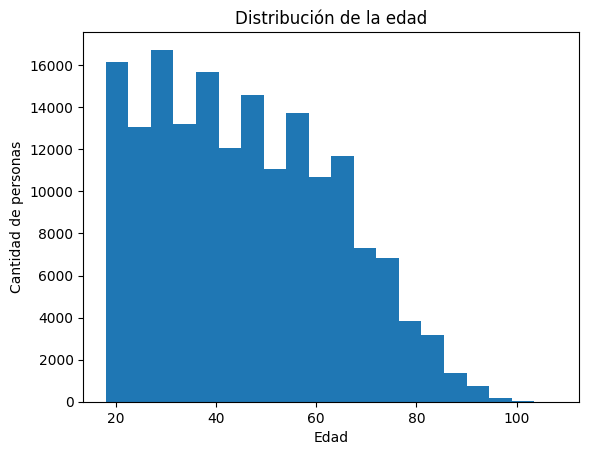

In [20]:
plt.hist(datos["P6040"], bins=20)

plt.title("Distribución de la edad")
plt.xlabel("Edad")
plt.ylabel("Cantidad de personas")

plt.show()


## 3.2 Satisfacción con la vida

In [21]:
print("Media:", round(datos["P1895"].mean(), 2))
print("Mediana:", datos["P1895"].median())
print("Mínimo:", datos["P1895"].min())
print("Máximo:", datos["P1895"].max())


Media: 8.14
Mediana: 8.0
Mínimo: 0.0
Máximo: 10.0


In [22]:
frecuencia_satisfaccion = datos["P1895"].value_counts().sort_index()

frecuencia_satisfaccion


P1895
0.0       526
1.0       207
2.0       571
3.0      1200
4.0      2112
5.0      7138
6.0     11226
7.0     24693
8.0     50090
9.0     31968
10.0    42294
Name: count, dtype: int64

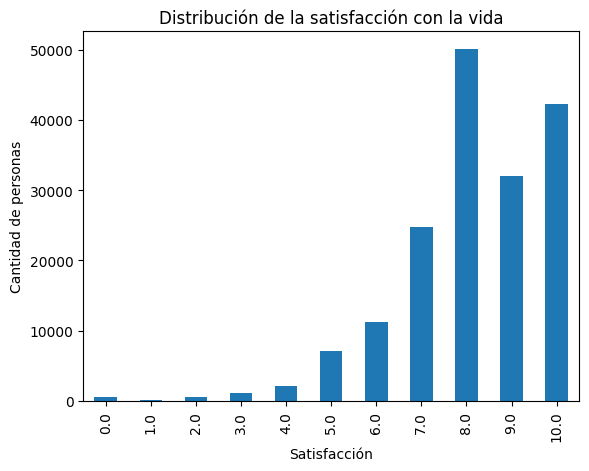

In [23]:
frecuencia_satisfaccion.plot(kind="bar")

plt.title("Distribución de la satisfacción con la vida")
plt.xlabel("Satisfacción")
plt.ylabel("Cantidad de personas")

plt.show()


## 3.3 Sexo

In [24]:
datos["sexo"].value_counts()


sexo
Mujer     90981
Hombre    81044
Name: count, dtype: int64

In [25]:
promedio_sexo = datos.groupby("sexo")["P1895"].mean()

promedio_sexo


sexo
Hombre    8.148228
Mujer     8.136875
Name: P1895, dtype: float64

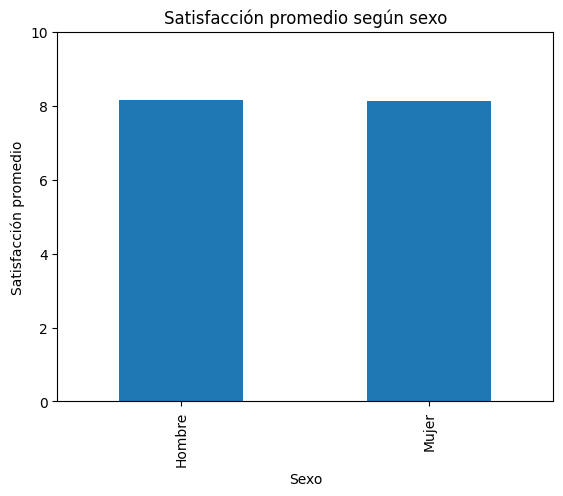

In [26]:
promedio_sexo.plot(kind="bar")

plt.title("Satisfacción promedio según sexo")
plt.xlabel("Sexo")
plt.ylabel("Satisfacción promedio")
plt.ylim(0, 10)

plt.show()


## 3.4 Grupo de edad

In [27]:
def grupo_edad(edad):
    if edad < 30:
        return "18-29"
    elif edad < 45:
        return "30-44"
    elif edad < 60:
        return "45-59"
    else:
        return "60 o más"

datos["grupo_edad"] = datos["P6040"].apply(grupo_edad)

datos["grupo_edad"].value_counts()


grupo_edad
30-44       47741
60 o más    43167
45-59       42001
18-29       39116
Name: count, dtype: int64

In [28]:
promedio_edad = datos.groupby("grupo_edad")["P1895"].mean()

promedio_edad


grupo_edad
18-29       8.235684
30-44       8.200163
45-59       8.146568
60 o más    7.989228
Name: P1895, dtype: float64

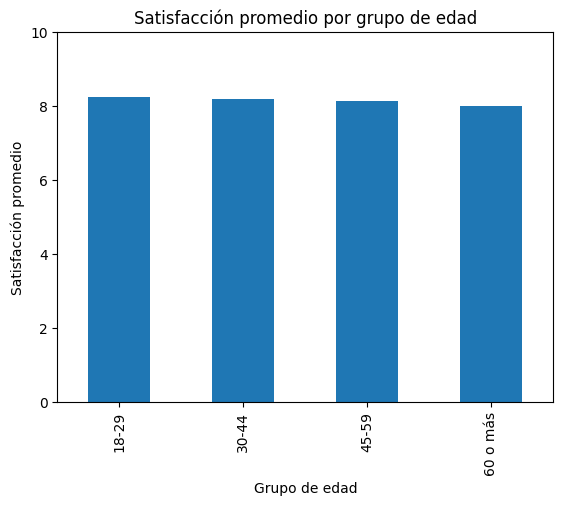

In [29]:
promedio_edad.plot(kind="bar")

plt.title("Satisfacción promedio por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Satisfacción promedio")
plt.ylim(0, 10)

plt.show()


## 3.5 Estado civil

In [30]:
datos["estado_civil"].value_counts()


estado_civil
Unión libre 2 años o más       56869
Soltero/a                      42767
Casado/a                       35757
Separado/a o divorciado/a      22337
Viudo/a                        10644
Unión libre menos de 2 años     3651
Name: count, dtype: int64

In [31]:
promedio_estado = datos.groupby("estado_civil")["P1895"].mean()

promedio_estado


estado_civil
Casado/a                       8.308555
Separado/a o divorciado/a      8.031696
Soltero/a                      8.119321
Unión libre 2 años o más       8.137667
Unión libre menos de 2 años    8.276363
Viudo/a                        7.885757
Name: P1895, dtype: float64

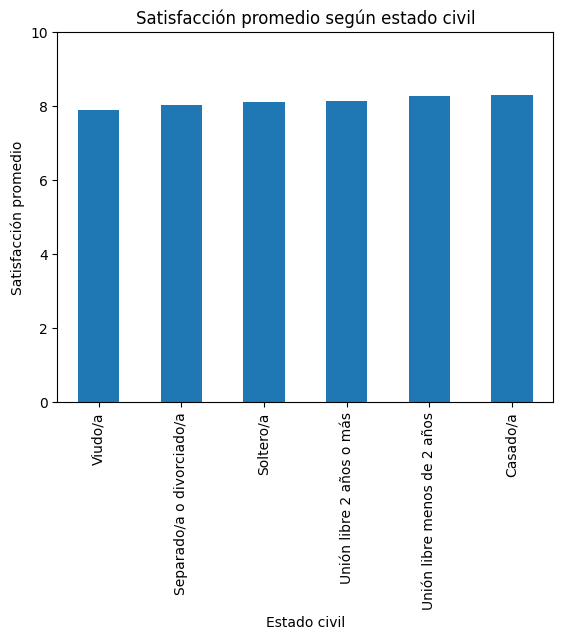

In [32]:
promedio_estado.sort_values().plot(kind="bar")

plt.title("Satisfacción promedio según estado civil")
plt.xlabel("Estado civil")
plt.ylabel("Satisfacción promedio")
plt.ylim(0, 10)

plt.show()


## 3.6 Asociación y causalidad

Las diferencias encontradas entre edad, sexo o estado civil y satisfacción con la vida muestran asociaciones descriptivas. No significa que estas características sean necesariamente la causa de la diferencia, porque también pueden influir aspectos como salud, ingresos, trabajo o condiciones familiares.


## 3.7 Posibles valores atípicos

In [33]:
q1 = datos["P6040"].quantile(0.25)
q3 = datos["P6040"].quantile(0.75)

rango = q3 - q1

limite_inferior = q1 - 1.5 * rango
limite_superior = q3 + 1.5 * rango

print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)


Límite inferior: -12.5
Límite superior: 103.5


In [34]:
edades_atipicas = datos[
    (datos["P6040"] < limite_inferior) |
    (datos["P6040"] > limite_superior)
]

print("Cantidad de posibles valores atípicos:", len(edades_atipicas))

edades_atipicas["P6040"].value_counts().sort_index()


Cantidad de posibles valores atípicos: 5


P6040
104    2
105    2
108    1
Name: count, dtype: int64

In [35]:
q1_sat = datos["P1895"].quantile(0.25)
q3_sat = datos["P1895"].quantile(0.75)

rango_sat = q3_sat - q1_sat

limite_inferior_sat = q1_sat - 1.5 * rango_sat
limite_superior_sat = q3_sat + 1.5 * rango_sat

atipicos_satisfaccion = datos[
    (datos["P1895"] < limite_inferior_sat) |
    (datos["P1895"] > limite_superior_sat)
]

print("Cantidad de posibles valores atípicos:", len(atipicos_satisfaccion))
print(atipicos_satisfaccion["P1895"].value_counts().sort_index())


Cantidad de posibles valores atípicos: 2504
P1895
0.0     526
1.0     207
2.0     571
3.0    1200
Name: count, dtype: int64


Los valores atípicos no se eliminan automáticamente. Las edades altas pueden ser observaciones reales y los valores bajos de satisfacción siguen siendo respuestas válidas dentro de la escala de 0 a 10.

## 3.8 Comparación final de los grupos

Para responder directamente la pregunta, ordenamos los promedios de satisfacción de menor a mayor en cada característica.


In [36]:
print("SATISFACCIÓN PROMEDIO POR GRUPO DE EDAD")
print(promedio_edad.sort_values())

print("\nSATISFACCIÓN PROMEDIO POR SEXO")
print(promedio_sexo.sort_values())

print("\nSATISFACCIÓN PROMEDIO POR ESTADO CIVIL")
print(promedio_estado.sort_values())


SATISFACCIÓN PROMEDIO POR GRUPO DE EDAD
grupo_edad
60 o más    7.989228
45-59       8.146568
30-44       8.200163
18-29       8.235684
Name: P1895, dtype: float64

SATISFACCIÓN PROMEDIO POR SEXO
sexo
Mujer     8.136875
Hombre    8.148228
Name: P1895, dtype: float64

SATISFACCIÓN PROMEDIO POR ESTADO CIVIL
estado_civil
Viudo/a                        7.885757
Separado/a o divorciado/a      8.031696
Soltero/a                      8.119321
Unión libre 2 años o más       8.137667
Unión libre menos de 2 años    8.276363
Casado/a                       8.308555
Name: P1895, dtype: float64


### 4. Hallazgos


1. El grupo de edad con menor satisfacción promedio fue el de más de 60 años, con un valor de 7,99.
2. Las personas viudas tienen el promedio mas bajo de satisfacción entre los estados civiles, su promedio es 7,89
3. El segundo lugar de peor satisfacción de los estados civiles son las personas separadas, con promedio de 8,03
4. La diferencia entre el promedio de satisfacción entre mujeres y hombres es de apenas 0,01, ya que en mujeres es de 8,14 y en hombres es de 8,15.

Estos datos, aunque nos pueden dar una perspectiva de ciertos factores que pueden afectar la satisfacción de las personas, no significa que por ser hombre, mayor de 60 años y viudo la felicidad sea menor en la mayoría de los casos (al menos no se puede deducir con los resultados de satisfacción) por ende, estos datos dan resultados descriptivos, pero no son suficientes para afirmar que alguien que cumpla con todas las características sea menos feliz.

No se eliminaron los valores atípicos porque no hay ninguna evidencia de que sean errores y pueden ser perfectamente datos válidos, se demostró tambien que tampoco hay causalidad entre edad, sexo, estado civil y satisfacción.

### 5. Reflexión

- Lo mas dificil fue tratar la satisfacción con la vida, ya que es un tema amplio y se puede prestar para análisis subjetivos, así que tuvimos que identificar cuáles eran las variables más relevantes para responder la pregunta de la manera más objetiva posible.

- Una decisión fue tratar el csv sin agregar nada a los datos faltantes para evitar sesgos, y filtrar únicamente personas mayores a 18 años, otra fue decidir que el analisís era descriptivo y no causal, ya que no podiamos afirmar cosas de causa-efecto.